In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
#Connect colab with drive
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
data=pd.read_csv('/content/drive/MyDrive/digit-recognizer/train (1).csv')
data=pd.read_csv('/content/train.csv')

In [5]:
data.head() #every row is a image. each row contains value of all 784 pixel values

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
data=np.array(data)
m,n=data.shape #m-no of images(rows), n- no of each pixels value of each image(columns)

In [8]:
np.random.shuffle(data)

In [11]:
print(m,n)

42000 785


In [16]:
train_data=data[0:int(0.8*m),:]#first 80% rows as training data
val_data=data[int(0.8*m):m,:]#last 20% data as validation data
X_train=train_data[:,1:]#getting all row values for each image( : ) and ignoring 0th column and counting from 1st column row because it is label
Y_train=train_data[:,0]#leaving 0th column as it is label
X_train=X_train.T # converting each column as a image from each row as a image as per neural network architecture
X_train=X_train/255.0 # normalising the value from 0 to 255 to 1 as255 is the max  pixel value
X_val=val_data[:,1:]
Y_val=val_data[:,0]
X_val=X_val.T
X_val=X_val/255.0

In [15]:
print(X_val.shape)
print(Y_val.shape)
print(X_train.shape)
print(Y_train.shape)

(784, 8400)
(8400,)
(784, 33600)
(33600,)


In [27]:
def initialize_parameters():
  W1=np.random.rand(10,784)-0.5  # array of 10 rows 784 coulmns as in equation. subtarcting 0.5 to limit all values below 0.5
  B1=np.random.rand(10,1)-0.5
  W2=np.random.rand(10,10)-0.5
  B2=np.random.rand(10,1)-0.5
  return  W1,B1,W2,B2

def ReLU(X):
  return np.maximum(0,X)


def softmax_calc(Z):
  return np.exp(Z)/sum(np.exp(Z))

def forward_propagation(W1,B1,W2,B2,X):
  Z1=W1.dot(X)+B1
  A1=ReLU(Z1)
  Z2=W2.dot(A1)+B2
  A2=softmax_calc(Z2)
  return Z1,A1,Z2,A2

def one_hot_converter(Y):
     one_hot_Y=np.zeros((Y.size,Y.max()+1))
     one_hot_Y[np.arange(Y.size),Y]=1;
     one_hot_Y=one_hot_Y.T
     return one_hot_Y

def backward_propagation(W1,B1,W2,B2,X,Y,Z1,A1,Z2,A2):
  one_hot_Y=one_hot_converter(Y)
  dZ2=A2-one_hot_Y
  dW2=1/m*dZ2.dot(A1.T)
  dB2=1/m*np.sum(dZ2)
  dZ1=W2.T.dot(dZ2)*(Z1>0)
  dW1=1/m*dZ1.dot(X.T)
  dB1=1/m*np.sum(dZ1)
  return dW1,dB1,dW2,dB2

def update_parameters(W1,W2,B1,B2,dW1,dB1,dW2,dB2,learning_rate):
  W1=W1-learning_rate*dW1
  B1=B1-learning_rate*dB1
  W2=W2-learning_rate*dW2
  B2=B2-learning_rate*dB2
  return W1,B1,W2,B2

def get_predictions(A2):
  return np.argmax(A2,0)

def get_accuracy(predictions,Y):
  return np.sum(predictions==Y)/Y.size

def gradient_descent(X,Y,alpha,iterations):
  W1,B1,W2,B2=initialize_parameters()
  for i in range(iterations):
    Z1,A1,Z2,A2=forward_propagation(W1,B1,W2,B2,X)
    dW1,dB1,dW2,dB2=backward_propagation(W1,B1,W2,B2,X,Y,Z1,A1,Z2,A2)
    W1,B1,W2,B2=update_parameters(W1,W2,B1,B2,dW1,dB1,dW2,dB2,alpha)
    if i%20==0:
      print("Iteration number :",i)
      print("Accuracy = ",get_accuracy(get_predictions(A2),Y))
  return W1,B1,W2,B2

In [28]:
W1,B1,W2,B2=gradient_descent(X_train,Y_train,0.1,1000)

Iteration number : 0
Accuracy =  0.07943452380952382
Iteration number : 20
Accuracy =  0.12949404761904762
Iteration number : 40
Accuracy =  0.20398809523809525
Iteration number : 60
Accuracy =  0.28964285714285715
Iteration number : 80
Accuracy =  0.350625
Iteration number : 100
Accuracy =  0.420625
Iteration number : 120
Accuracy =  0.48723214285714284
Iteration number : 140
Accuracy =  0.5398511904761905
Iteration number : 160
Accuracy =  0.5866666666666667
Iteration number : 180
Accuracy =  0.6288988095238095
Iteration number : 200
Accuracy =  0.6612202380952381
Iteration number : 220
Accuracy =  0.6860714285714286
Iteration number : 240
Accuracy =  0.7063095238095238
Iteration number : 260
Accuracy =  0.723125
Iteration number : 280
Accuracy =  0.7381547619047619
Iteration number : 300
Accuracy =  0.7508035714285715
Iteration number : 320
Accuracy =  0.7622619047619048
Iteration number : 340
Accuracy =  0.7708333333333334
Iteration number : 360
Accuracy =  0.7794940476190476
Itera

Predicted Label:  [1]
Actual Label:  1


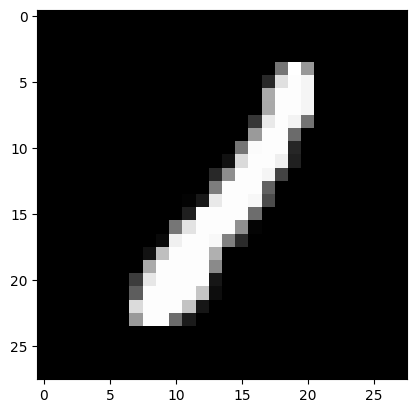

In [30]:
val_index=0
Z1val,A1val,Z2val,A2val=forward_propagation(W1,B1,W2,B2,X_val[:,val_index,None])
print("Predicted Label: " ,get_predictions(A2val))
print("Actual Label: ",Y_val[val_index])
image_array=X_val[:,val_index].reshape(28,28)
plt.imshow(image_array,cmap='gray')
plt.show()


In [31]:
Z1val,A1val,Z2val,A2val=forward_propagation(W1,B1,W2,B2,X_val[:,val_index,None])
acc_val=get_accuracy(get_predictions(A2val),Y_val)
print("Validation Accuracy = ",acc_val)

Validation Accuracy =  0.11071428571428571
